In [1]:
%pip install neurogym

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import neurogym as ngym
env = ngym.make('DelayMatchSampleDistractor1D-v0')

Additionally, Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/Users/michaelcai/Library/Python/3.9/lib/python/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/Users/michaelcai/Library/Python/3.9/lib/python/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/Users/michaelcai/Library/Python/3.9/lib/python/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'res

In [3]:
import numpy as np

In [4]:
from neurogym.envs.delaymatchsample import DelayMatchSampleDistractor1D


In [5]:
X = []
Y = []
env = DelayMatchSampleDistractor1D()
N = 5
for _ in range(N):
    env.new_trial()
    # input sequence
    x_trial = env.ob # shape: (T, 33)

    # correct labels
    y_trial = env.gt # shape: (T,)
    
    X.append(x_trial)
    Y.append(y_trial)

X = np.stack(X) # shape: (N, T, 33)
Y = np.stack(Y)  # shape: (N, T)


In [6]:
X

array([[[ 1.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 1.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 1.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        , -0.5966556 , -0.74175054, ..., -0.05025734,
         -0.24413544, -0.42863157],
        [ 0.        , -0.5966556 , -0.74175054, ..., -0.05025734,
         -0.24413544, -0.42863157],
        [ 0.        , -0.5966556 , -0.74175054, ..., -0.05025734,
         -0.24413544, -0.42863157]],

       [[ 1.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 1.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 1.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        , -0.7889393 , -0.8936574 , ..., -

# RNN

In [7]:
%pip install torch

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [9]:
"""
FROM DOCS
class DelayMatchSampleDistractor1D(ngym.TrialEnv):
    Delayed match-to-sample with multiple, potentially repeating
    distractors.

    A sample stimulus is shown during the sample period. The stimulus is
    characterized by a one-dimensional variable, such as its orientation
    between 0 and 360 degree. After a delay period, the first test stimulus is
    shown. The agent needs to determine whether the sample and this test
    stimuli are equal. If so, it needs to produce the match response. If the
    first test is not equal to the sample stimulus, another delay period and
    then a second test stimulus follow, and so on.

    metadata = {
        'paper_link': 'https://www.jneurosci.org/content/jneuro/16/16/' +
        '5154.full.pdf',
        'paper_name': '''Neural Mechanisms of Visual Working Memory
        in Prefrontal Cortex of the Macaque''',
        'tags': ['perceptual', 'working memory', 'two-alternative',
                 'supervised']
    }

    def __init__(self, dt=100, rewards=None, timing=None, sigma=1.0):
        super().__init__(dt=dt)
        self.choices = [1, 2, 3]
        self.sigma = sigma / np.sqrt(self.dt)  # Input noise

        # Rewards
        self.rewards = {'abort': -0.1, 'correct': +1., 'fail': -1.}
        if rewards:
            self.rewards.update(rewards)

        self.timing = {
            'fixation': 300,
            'sample': 500,
            'delay1': 1000,
            'test1': 500,
            'delay2': 1000,
            'test2': 500,
            'delay3': 1000,
            'test3': 500}
        if timing:
            self.timing.update(timing)

        self.abort = False

        self.theta = np.arange(0, 2 * np.pi, 2 * np.pi / 32)
#!!!!!! ^^ initializes the preferred angles for each neuron - each neuron's preferred angle is 2pi/32 radians apart (evenly distributed around unit circle) !!!!!

        name = {'fixation': 0, 'stimulus': range(1, 33)}
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(33,),
                                            dtype=np.float32, name=name)

        name = {'fixation': 0, 'match': 1}
        self.action_space = spaces.Discrete(2, name=name)

    def _new_trial(self, **kwargs):
        trial = {
            # There is always a match, ground_truth is which test is a match
            'ground_truth': self.rng.choice(self.choices),
            'sample': self.rng.uniform(0, 2*np.pi),
#!!!!!! ^^ initializes the sample stimulus to a random angle between 0 and 2pi !!!!!
        }
        trial.update(kwargs)

        ground_truth = trial['ground_truth']
        sample = trial['sample']
        for i in [1, 2, 3]:
            tmp = sample if i == ground_truth else self.rng.uniform(0, 2*np.pi)
            trial['test'+str(i)] = tmp
#!!!!!!!!!!!^^^ forms the false "distractor" stimuli for the tests during each working memory task!!!!!!!!!

        periods = ['fixation', 'sample', 'delay1', 'test1',
                   'delay2', 'test2', 'delay3', 'test3']
        self.add_period(periods)

        self.add_ob(1, 'fixation', where='fixation')
        for period in ['sample', 'test1', 'test2', 'test3']:
            self.add_ob(np.cos(self.theta - trial[period]), period, 'stimulus')
#!!!!!!!! ^^ this is the part that creates the stimulus vector based on cos(φ_i-θ)!!!!!!
        self.set_groundtruth(1, 'test'+str(ground_truth))

        return trial

    def _step(self, action):
        new_trial = False
        reward = 0

        ob = self.ob_now
        gt = self.gt_now
        if ((self.in_period('fixation') or self.in_period('sample')) and
                action != 0):
            reward = self.rewards['abort']
            new_trial = self.abort
        elif not self.in_period('test'+str(self.trial['ground_truth'])):
            if action != 0:
                reward = self.rewards['fail']
                new_trial = True
        else:
            if action == 1:
                reward = self.rewards['correct']
                new_trial = True
                self.performance = 1

        return ob, reward, False, {'new_trial': new_trial, 'gt': gt}

"""

'\nFROM DOCS\nclass DelayMatchSampleDistractor1D(ngym.TrialEnv):\n    Delayed match-to-sample with multiple, potentially repeating\n    distractors.\n\n    A sample stimulus is shown during the sample period. The stimulus is\n    characterized by a one-dimensional variable, such as its orientation\n    between 0 and 360 degree. After a delay period, the first test stimulus is\n    shown. The agent needs to determine whether the sample and this test\n    stimuli are equal. If so, it needs to produce the match response. If the\n    first test is not equal to the sample stimulus, another delay period and\n    then a second test stimulus follow, and so on.\n\n    metadata = {\n        \'paper_link\': \'https://www.jneurosci.org/content/jneuro/16/16/\' +\n        \'5154.full.pdf\',\n        \'paper_name\': \'\'\'Neural Mechanisms of Visual Working Memory\n        in Prefrontal Cortex of the Macaque\'\'\',\n        \'tags\': [\'perceptual\', \'working memory\', \'two-alternative\',\n        

## MAIN OG

In [10]:
# def generate_trials(num_trials=1000, distractor_strength=1.0, seed=42):
#     """Generate trials for the memory task using NeuroGym."""

#     seed = 42 # 67 
#     rng = np.random.RandomState(seed)
#     env = DelayMatchSampleDistractor1D(dt=20) # dt determines how long each delay / test period is (the test is like fixation + sample + delay1 + test1 + delay2 + test2 + delay3 + test3)
#     # also, the sample here is Unif(0, 2pi) and is the angle of the stimulus
#     # fixation tells the network to stay still and not respond yet

#     all_inputs = []
#     all_labels = []

#     for _ in range(num_trials):
#         env.new_trial()
#         # reminder of format:
#         # env.ob: network input at each timestep, shape (T, 33)
#         # column 0 = fixation signal, columns 1-32 = population-coded stimulus
#         # env.gt: correct label at each timestep, shape (T,)
#         # 0 = do nothing, 1 = match
#         all_inputs.append(env.ob.copy())
#         all_labels.append(env.gt.copy())

#     X = np.stack(all_inputs) # (num_trials, T, 33)
#     Y = np.stack(all_labels) # (num_trials, T)
#     return X, Y



In [11]:
import os

In [12]:
# # Main


# # Settings for hyperparameters
# NUM_TRAIN_TRIALS = 2000
# NUM_VAL_TRIALS = 400
# BATCH_SIZE = 64
# NUM_EPOCHS = 100
# LEARNING_RATE = 5e-4
# HIDDEN_SIZE = 64
# CHECKPOINT_EVERY = 10
# DISTRACTOR_STRENGTH = 1.0 

# DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# print(f"Using device: {DEVICE}")

# # Generate data using NeuroGym
# print("Generating training trials...")
# X_train, Y_train = generate_trials(
#     num_trials=NUM_TRAIN_TRIALS,
#     distractor_strength=DISTRACTOR_STRENGTH,
#     seed=42,
# )
# print(f"Input shape:  {X_train.shape}")
# print(f"Labels shape: {Y_train.shape}")
# print(f"Unique labels: {np.unique(Y_train)}")

# print("Generating validation trials...")
# X_val, Y_val = generate_trials(
#     num_trials=NUM_VAL_TRIALS,
#     distractor_strength=DISTRACTOR_STRENGTH,
#     seed=99,
# )

# # Compute class weights to handle imbalance
# # (most timesteps are "do nothing", only ~10% are actual decisions)
# num_classes = len(np.unique(Y_train))
# class_counts = np.bincount(Y_train.flatten(), minlength=num_classes)
# total_samples = class_counts.sum()
# class_weights = torch.tensor(
#     total_samples / (num_classes * class_counts),
#     dtype=torch.float32,
# )
# print(f"  Class counts: {dict(enumerate(class_counts))}")
# print(f"  Class weights: {class_weights.tolist()}")

# # Set up data loaders
# train_loader = DataLoader(
#     TrialDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True
# )
# val_loader = DataLoader(
#     TrialDataset(X_val, Y_val), batch_size=BATCH_SIZE, shuffle=False
# )

# # Create and train the model
# model = VanillaRNN(
#     input_size=33,
#     hidden_size=HIDDEN_SIZE,
#     output_size=num_classes,
# )
# print(f"\nModel architecture:\n{model}")
# print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters()):,}")
# return 
# checkpoint_dir = os.path.join('checkpoints', f'distractor_{DISTRACTOR_STRENGTH}')
# history = train_model(
#     model, train_loader, val_loader=val_loader,
#     num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
#     checkpoint_dir=checkpoint_dir, checkpoint_every=CHECKPOINT_EVERY,
#     device=DEVICE, class_weights=class_weights,
# )

# # Extract hidden states for later analysis (PCA, stability, etc.)
# print("\nExtracting hidden states from trained model...")
# hidden_states = extract_hidden_states(model, X_val[:50], device=DEVICE)
# print(f"Hidden states shape: {hidden_states.shape}")
# np.save(os.path.join(checkpoint_dir, 'hidden_states_val.npy'), hidden_states)
# print(f"Saved to {checkpoint_dir}/hidden_states_val.npy")

# # Save training history for plotting learning curves
# np.savez(
#     os.path.join(checkpoint_dir, 'training_history.npz'),
#     train_loss=history['train_loss'], train_acc=history['train_acc'],
#     train_dec_acc=history['train_dec_acc'], val_loss=history['val_loss'],
#     val_acc=history['val_acc'], val_dec_acc=history['val_dec_acc'],
# )
# print("Done! Training history saved.")




In [14]:
X_train[0]
"""
data format of X_train[0] (the first input of train data):
rows 0–14:   [1, 0, 0, ..., 0]                  ← fixation (repeated)
rows 15–39:  [0, stim1[0], ..., stim1[31]]      ← sample stimulus (same vector repeated)
rows 40–89:  [0, 0, 0, ..., 0]                  ← delay (repeated)
rows 90–114: [0, test1[0], ..., test1[31]]      ← test1 (repeated); could be the "distractor" or the actual stimulus
rows 115–... more delay/test blocks
where row t is a time step in the working memory task; 
stimuli/tests are 33-d vectors since each (apart from v_0 which is the channel that denotes fixation/not fixating)
v_1...v_32 is v_i=cos(φ_i-θ) where φ_i is the preferred angle for neuron i, and θ is the angle in
question that the stimulus is testing (either the reference stimulus or a test stimulus)

data format of Y_train[0] (the first label of train data):
rows 0–14:   0                  ← returns 0 for these time steps bc holding during fixation
rows 15–39:  0     ← returns 0 for these time steps bc holding during sample stimulus
rows 40–89:  0                  ← returns 0 for these time steps bc holding duringdelay
rows 90–114: 1 or 0      ← based on whether the test1 stimulus matches the sample stimulus or the distractor
rows 115–... more responses to delay/test blocks
"""

NameError: name 'X_train' is not defined

In [15]:
Y_train[0][0]

NameError: name 'Y_train' is not defined

In [16]:
print(X.shape)

(5, 53, 33)


In [17]:
# import numpy as np

# def apply_distractor_scaling(X, Y, alpha):
#     """
#     X: (N, T, 33)
#     Y: (N, T)
#     alpha: scalar

#     Returns:
#         X2 with distractor stimulus scaled by alpha
#     """
#     X2 = X.copy()

#     # stimulus present when any of the 32 channels are nonzero
#     stimulus_present = np.linalg.norm(X[:, :, 1:], axis=2) > 0

#     # distractor = stimulus present AND not match (Y == 0)
#     distractor_mask = (stimulus_present) & (Y == 0)

#     # apply scaling only to stimulus channels (1:33)
#     X2[distractor_mask, 1:] *= alpha

#     return X2

# Xdistractor = apply_distractor_scaling(X, Y, 2)

In [18]:
import numpy as np

print(X)
print(Y)

[[[ 1.          0.          0.         ...  0.          0.
    0.        ]
  [ 1.          0.          0.         ...  0.          0.
    0.        ]
  [ 1.          0.          0.         ...  0.          0.
    0.        ]
  ...
  [ 0.         -0.5966556  -0.74175054 ... -0.05025734 -0.24413544
   -0.42863157]
  [ 0.         -0.5966556  -0.74175054 ... -0.05025734 -0.24413544
   -0.42863157]
  [ 0.         -0.5966556  -0.74175054 ... -0.05025734 -0.24413544
   -0.42863157]]

 [[ 1.          0.          0.         ...  0.          0.
    0.        ]
  [ 1.          0.          0.         ...  0.          0.
    0.        ]
  [ 1.          0.          0.         ...  0.          0.
    0.        ]
  ...
  [ 0.         -0.7889393  -0.8936574  ... -0.31459713 -0.49373692
   -0.65390265]
  [ 0.         -0.7889393  -0.8936574  ... -0.31459713 -0.49373692
   -0.65390265]
  [ 0.         -0.7889393  -0.8936574  ... -0.31459713 -0.49373692
   -0.65390265]]

 [[ 1.          0.          0.      

In [19]:
# import numpy as np
# import torch

# def paper_fidelity_from_input(model, decoder, X_input, theta_true, device='cpu'):
#     """
#     Compute paper-style fidelity from an input set (e.g. X or X2).

#     Parameters
#     ----------
#     model : trained RNN
#         Should return (predictions, hidden_states) when called on X_input.
#     decoder : callable
#         Maps hidden states -> reconstructed channel responses over angles.
#         Expected input/output:
#             input:  (N*T, H)
#             output: (N*T, K)
#         where K is the number of angle bins / channels in the reconstruction.
#     X_input : np.ndarray
#         Shape (N, T, 33)
#     theta_true : np.ndarray
#         Shape (N,)
#         True sample angle for each trial, in radians.
#     device : str
#         'cpu' or 'cuda'

#     Returns
#     -------
#     fidelity_t : np.ndarray
#         Shape (T,)
#         Mean fidelity across trials at each time step.
#     recon_aligned : np.ndarray
#         Shape (N, T, K)
#         Angle-aligned reconstructed channel responses.
#     theta_grid_centered : np.ndarray
#         Shape (K,)
#         Angle grid after centering true angle at 0.
#     """

#     model.eval()

#     # 1) Run input through RNN and get hidden states
#     X_tensor = torch.tensor(X_input, dtype=torch.float32, device=device)
#     with torch.no_grad():
#         _, hidden_states = model(X_tensor)   # (N, T, H)

#     hidden_states = hidden_states.detach().cpu().numpy()
#     N, T, H = hidden_states.shape

#     # 2) Decode / reconstruct channel responses from hidden states
#     hidden_flat = hidden_states.reshape(N * T, H)

#     with torch.no_grad():
#         hidden_flat_torch = torch.tensor(hidden_flat, dtype=torch.float32, device=device)
#         recon_flat = decoder(hidden_flat_torch).detach().cpu().numpy()  # (N*T, K)

#     recon = recon_flat.reshape(N, T, -1)  # (N, T, K)
#     K = recon.shape[-1]

#     # 3) Build angle grid for the reconstruction channels
#     theta_grid = np.linspace(0, 2 * np.pi, K, endpoint=False)

#     # 4) Align each trial so the true sample angle is at 0
#     #    This matches the paper logic: align reconstruction to the true remembered angle.
#     recon_aligned = np.zeros_like(recon)

#     for n in range(N):
#         # shift amount in bins
#         shift_bins = int(np.round((theta_true[n] / (2 * np.pi)) * K)) % K

#         # roll so theta_true is centered at 0
#         recon_aligned[n] = np.roll(recon[n], -shift_bins, axis=-1)

#     # centered grid after alignment
#     theta_grid_centered = np.linspace(0, 2 * np.pi, K, endpoint=False)

#     # 5) Paper-style fidelity:
#     #    F(t) = mean_theta( r(theta) * cos(theta) )
#     # after alignment, true angle is at 0
#     cos_weights = np.cos(theta_grid_centered)  # (K,)

#     fidelity_trials_t = np.mean(recon_aligned * cos_weights[None, None, :], axis=-1)  # (N, T)
#     fidelity_t = fidelity_trials_t.mean(axis=0)  # (T,)

#     return fidelity_t, recon_aligned, theta_grid_centered

In [20]:
# import matplotlib.pyplot as plt
# fidelity_X, _, _ = paper_fidelity_from_input(model, decoder, X, theta_true, device='cpu')
# fidelity_X2, _, _ = paper_fidelity_from_input(model, decoder, X2, theta_true, device='cpu')

# plt.plot(fidelity_X, label='X (baseline)')
# plt.plot(fidelity_X2, label='X2 (with scaled distractor)')
# plt.xlabel('Time step')
# plt.ylabel('Fidelity')
# plt.legend()
# plt.show()

## MAIN NEW

In [21]:
# # Main 2
# from gym import spaces
# class DelayMatchSampleDistractor1D(ngym.TrialEnv):
#     def __init__(self, dt=100, rewards=None, timing=None, sigma=1.0):
#         """ Delayed match-to-sample with multiple, potentially repeating
#         distractors.

#         A sample stimulus is shown during the sample period. The stimulus is
#         characterized by a one-dimensional variable, such as its orientation
#         between 0 and 360 degree. After a delay period, the first test stimulus is
#         shown. The agent needs to determine whether the sample and this test
#         stimuli are equal. If so, it needs to produce the match response. If the
#         first test is not equal to the sample stimulus, another delay period and
#         then a second test stimulus follow, and so on.

#         metadata = {
#             'paper_link': 'https://www.jneurosci.org/content/jneuro/16/16/' +
#             '5154.full.pdf',
#             'paper_name': '''Neural Mechanisms of Visual Working Memory
#             in Prefrontal Cortex of the Macaque''',
#             'tags': ['perceptual', 'working memory', 'two-alternative',
#                     'supervised']
#         }
#         """
#         print("USING CUSTOM FN")
#         super().__init__(dt=dt)
#         self.choices = [1, 2, 3]
#         self.sigma = sigma / np.sqrt(self.dt)  # Input noise

#         # Rewards
#         self.rewards = {'abort': -0.1, 'correct': +1., 'fail': -1.}
#         if rewards:
#             self.rewards.update(rewards)

#         self.timing = {
#             'fixation': 300,
#             'sample': 500,
#             'delay1': 1000,
#             'test1': 500,
#             'delay2': 1000,
#             'test2': 500,
#             'delay3': 1000,
#             'test3': 500}
#         if timing:
#             self.timing.update(timing)

#         self.abort = False

#         self.theta = np.arange(0, 2 * np.pi, 2 * np.pi / 32)
#     #!!!!!! ^^ initializes the preferred angles for each neuron - each neuron's preferred angle is 2pi/32 radians apart (evenly distributed around unit circle) !!!!!

#         name = {'fixation': 0, 'stimulus': range(1, 33)}
#         self.observation_space = spaces.Box(-np.inf, np.inf, shape=(33,),
#                                             dtype=np.float32)

#         name = {'fixation': 0, 'match': 1}
#         self.action_space = spaces.Discrete(2)

#     def _new_trial(self, **kwargs):
#         trial = {
#             # There is always a match, ground_truth is which test is a match
#             'ground_truth': self.rng.choice(self.choices),
#             'sample': self.rng.uniform(0, 2*np.pi),
#     #!!!!!! ^^ initializes the sample stimulus to a random angle between 0 and 2pi !!!!!
#         }
#         trial.update(kwargs)

#         ground_truth = trial['ground_truth']
#         sample = trial['sample']
#         for i in [1, 2, 3]:
#             tmp = sample if i == ground_truth else self.rng.uniform(0, 2*np.pi)
#             trial['test'+str(i)] = tmp
#     #!!!!!!!!!!!^^^ forms the false "distractor" stimuli for the tests during each working memory task!!!!!!!!!

#         periods = ['fixation', 'sample', 'delay1', 'test1',
#                     'delay2', 'test2', 'delay3', 'test3']
#         self.add_period(periods)

#         self.add_ob(1, 'fixation', where='fixation')
#         for period in ['sample', 'test1', 'test2', 'test3']:
#             self.add_ob(np.cos(self.theta - trial[period]), period, 'stimulus')
#     #!!!!!!!! ^^ this is the part that creates the stimulus vector based on cos(φ_i-θ)!!!!!!
#         self.set_groundtruth(1, 'test'+str(ground_truth))

#         return trial

#     def _step(self, action):
#         new_trial = False
#         reward = 0

#         ob = self.ob_now
#         gt = self.gt_now
#         if ((self.in_period('fixation') or self.in_period('sample')) and
#                 action != 0):
#             reward = self.rewards['abort']
#             new_trial = self.abort
#         elif not self.in_period('test'+str(self.trial['ground_truth'])):
#             if action != 0:
#                 reward = self.rewards['fail']
#                 new_trial = True
#         else:
#             if action == 1:
#                 reward = self.rewards['correct']
#                 new_trial = True
#                 self.performance = 1

#         return ob, reward, False, {'new_trial': new_trial, 'gt': gt}





In [22]:
import numpy as np

def add_poisson_delay_distractors(X, delay_blocks, lam=3.0, seed=42):
    """
    Replace Pois(lam) timesteps inside each delay block with random-angle vectors.

    Parameters
    ----------
    X : np.ndarray
        Shape (N, T, 33)
    delay_blocks : list of tuples
        Each tuple is (start, end), end exclusive
    lam : float
        Poisson rate per delay block
    seed : int
        Random seed

    Returns
    -------
    X2 : np.ndarray
        Modified copy of X
    distractor_mask : np.ndarray
        Shape (N, T), True where a distractor was inserted
    """
    rng = np.random.RandomState(seed)
    X2 = X.copy()
    N, T, D = X.shape

    if D != 33:
        raise ValueError(f"Expected X.shape[2] = 33, got {D}")

    phi = np.arange(0, 2 * np.pi, 2 * np.pi / 32)
    distractor_mask = np.zeros((N, T), dtype=bool)

    for n in range(N):
        for start, end in delay_blocks:
            if start < 0 or end > T or start >= end:
                continue

            block_len = end - start
            k = min(rng.poisson(lam), block_len)

            if k == 0:
                continue

            chosen_times = rng.choice(np.arange(start, end), size=k, replace=False)

            for t in chosen_times:
                theta = rng.uniform(0, 2 * np.pi)
                # X2[n, t, 0] = 0.0
                X2[n, t, 1:] = np.cos(phi - theta)
                distractor_mask[n, t] = True

    return X2, distractor_mask

# get the delay blocks
def get_delay_blocks_from_env(env):
    """
    Convert env.timing into delay index ranges (start, end) in timestep units.

    Returns
    -------
    delay_blocks : list of tuples
        [(start1, end1), (start2, end2), ...]
    """

    dt = env.dt
    timing = env.timing

    # Order matters (same as in add_period)
    periods = ['fixation', 'sample', 'delay1', 'test1',
               'delay2', 'test2', 'delay3', 'test3']

    delay_blocks = []
    t = 0  # running timestep index

    for p in periods:
        duration_ms = timing[p]
        steps = int(duration_ms / dt)

        start = t
        end = t + steps

        if 'delay' in p:
            delay_blocks.append((start, end))

        t = end

    return delay_blocks


In [23]:
# new
def get_test_period_mask(env, T):
    """Returns a boolean array of shape (T,), True during any test period."""
    dt = env.dt
    periods = ['fixation', 'sample', 'delay1', 'test1',
               'delay2', 'test2', 'delay3', 'test3']
    mask = np.zeros(T, dtype=bool)
    t = 0
    for p in periods:
        steps = int(env.timing[p] / dt)
        if p.startswith('test'):
            mask[t:t+steps] = True
        t += steps
    return mask
def generate_trials2(num_trials=1000, distractor_strength=1.0, seed=42):
    """Generate trials for the memory task using NeuroGym."""

    # seed = 42 # makes distractor injection identical across train and val
    rng = np.random.RandomState(seed)
    env = DelayMatchSampleDistractor1D(dt=20) # dt determines how long each delay / test period is (the test is like fixation + sample + delay1 + test1 + delay2 + test2 + delay3 + test3)
    # also, the sample here is Unif(0, 2pi) and is the angle of the stimulus
    # fixation tells the network to stay still and not respond yet

    all_inputs = []
    all_labels = []
    all_samples = []
    all_gts = []

    for _ in range(num_trials):
        env.new_trial()
        # reminder of format:
        # env.ob: network input at each timestep, shape (T, 33)
        # column 0 = fixation signal, columns 1-32 = population-coded stimulus
        # env.gt: correct label at each timestep, shape (T,)
        # 0 = do nothing, 1 = match
        all_inputs.append(env.ob.copy())
        all_labels.append(env.gt.copy())
        all_samples.append(env.trial['sample'])
        all_gts.append(env.trial['ground_truth'])

    X = np.stack(all_inputs) # (num_trials, T, 33)
    Y = np.stack(all_labels) # (num_trials, T)
    Xtuple = add_poisson_delay_distractors(X, get_delay_blocks_from_env(env), lam=distractor_strength)
    Xnew, distractor_mask = Xtuple

    trial_info = {
        'sample_angle': np.array(all_samples), # shape (num_trials,)
        'ground_truth': np.array(all_gts), # shape (num_trials,)
    }

    test_mask_1d = get_test_period_mask(env, X.shape[1])  # shape (T,)
    test_mask = np.broadcast_to(test_mask_1d, (X.shape[0], X.shape[1])).copy() # (N, T)


    return Xnew, Y, test_mask, trial_info, distractor_mask


class TrialDataset(Dataset):
    def __init__(self, X, Y, test_mask):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)
        self.M = torch.tensor(test_mask, dtype=torch.bool) # mask

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.M[idx]

In [24]:



# one forward pass through the RNN performs one working memory matching task
class VanillaRNN(nn.Module):
    """
    Input = 33 -> 64 recurrent neurons -> Decision (2)

    We use a vanilla RNN (not more advanced versions like LSTM) so the recurrent weight matrix W_hh
    directly represents neuron-to-neuron connection strengths, making it easy
    to analyze like a biological wiring diagram. 64 hidden units is standard
    in computational neuroscience it appears and is not super hard to study.
    """

    def __init__(self, input_size=33, hidden_size=64, output_size=2):
        super().__init__()
        self.hidden_size = hidden_size
        # Recurrent layer with two weight matrices:
        # W_ih: input-to-neuron connections (33 x 64)
        # W_hh: neuron-to-neuron connections (64 x 64), our main analysis target
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            nonlinearity='tanh',
            batch_first=True,
        )

        # readout layer reads population activity, outputs a decision
        self.readout = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None):
        """Run input through the network. Returns predictions and hidden states."""
        hidden_states, _ = self.rnn(x, h0)
        predictions = self.readout(hidden_states)
        return predictions, hidden_states


# Training
def train_model(
    model, train_loader, val_loader=None, num_epochs=50, learning_rate=1e-3,
    checkpoint_dir='checkpoints', checkpoint_every=10, device='cpu',
    class_weights=None,
):
    """Train the RNN and saves checkpoints"""

    os.makedirs(checkpoint_dir, exist_ok=True)
    model = model.to(device)

    # Cross-entropy loss with class weighting -> important so the network can't cheat by always predicting "do nothing" (90% of timesteps)
    loss_function = nn.CrossEntropyLoss(
        weight=class_weights.to(device) if class_weights is not None else None
    )

    # we use default Adam optimizer for now
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [], 'train_acc': [], 'train_dec_acc': [],
        'val_loss': [], 'val_acc': [], 'val_dec_acc': [],
    }

    for epoch in range(1, num_epochs + 1):

        # Train on batches
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        dec_correct = 0
        dec_total = 0

        for inputs_batch, labels_batch, mask_batch in train_loader:
            inputs_batch = inputs_batch.to(device)
            labels_batch = labels_batch.to(device)
            mask_batch = mask_batch.to(device)

            predictions, _ = model(inputs_batch)

            # Masked loss: only compute CE on test-period timesteps
            preds_flat = predictions.reshape(-1, predictions.size(-1))
            labels_flat = labels_batch.reshape(-1)
            mask_flat = mask_batch.reshape(-1)

            loss = loss_function(preds_flat[mask_flat], labels_flat[mask_flat])
            probs = torch.softmax(predictions, dim=-1)
            entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=-1)

            loss = loss + 0.01 * (-entropy.mean())  # encourage higher entropy

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * inputs_batch.size(0)
            predicted_classes = predictions.argmax(dim=-1)

            # Test-period decision accuracy (catches "always say match")
            if mask_batch.any():
                dec_correct += (predicted_classes[mask_batch] == labels_batch[mask_batch]).sum().item()
                dec_total += mask_batch.sum().item()

            # Overall accuracy across all timesteps (for reference only)
            correct += (predicted_classes == labels_batch).sum().item()
            total += labels_batch.numel()
            

            # #  decision accuracy 
            # test_mask = get_test_period_mask(env, X.shape[1])  # shape (T,)
            # test_mask = np.broadcast_to(test_mask, (X.shape[0], X.shape[1]))  # (N, T)
            # is_decision = (labels_batch == 1)
            # is_test = test_mask_batch.bool()
            # if is_test.any():
            #     dec_correct += (predicted_classes[is_test] == labels_batch[is_test]).sum().item()
            #     dec_total += is_test.sum().item()
        # Record epoch metrics
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total
        train_dec_acc = dec_correct / dec_total if dec_total > 0 else 0.0

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_dec_acc'].append(train_dec_acc)

        # Validate
        val_loss, val_acc, val_dec_acc = None, None, None
        if val_loader is not None:
            val_loss, val_acc, val_dec_acc = evaluate(
                model, val_loader, loss_function, device
            )
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['val_dec_acc'].append(val_dec_acc)

        # Print progress
        msg = f"Epoch {epoch:3d}/{num_epochs} | "
        msg += f"Loss: {train_loss:.4f}  DecAcc: {train_dec_acc:.4f}"
        if val_loss is not None:
            msg += f" | ValLoss: {val_loss:.4f}  ValDecAcc: {val_dec_acc:.4f}"
        print(msg)

        # Save checkpoint with recurrent weight matrix for analysis
        if epoch % checkpoint_every == 0 or epoch == num_epochs:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'train_acc': train_acc,
                'val_loss': val_loss,
                'val_acc': val_acc,
                'W_hh': model.rnn.weight_hh_l0.detach().cpu().numpy(),
                'W_ih': model.rnn.weight_ih_l0.detach().cpu().numpy(),
            }
            path = os.path.join(checkpoint_dir, f'epoch_{epoch:03d}.pt')
            torch.save(checkpoint, path)
            print(f"  -> Checkpoint saved: {path}")

    return history


def evaluate(model, loader, loss_function, device='cpu'):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    dec_correct = 0
    dec_total = 0

    with torch.no_grad():
        for inputs_batch, labels_batch, mask_batch in loader:
            inputs_batch = inputs_batch.to(device)
            labels_batch = labels_batch.to(device)
            mask_batch = mask_batch.to(device)

            predictions, _ = model(inputs_batch)
            preds_flat = predictions.reshape(-1, predictions.size(-1))
            labels_flat = labels_batch.reshape(-1)
            mask_flat = mask_batch.reshape(-1)

            loss = loss_function(preds_flat[mask_flat], labels_flat[mask_flat])
            total_loss += loss.item() * inputs_batch.size(0)

            predicted_classes = predictions.argmax(dim=-1)
            correct += (predicted_classes == labels_batch).sum().item()
            total += labels_batch.numel()

            if mask_batch.any():
                dec_correct += (predicted_classes[mask_batch] == labels_batch[mask_batch]).sum().item()
                print("PRED", predicted_classes[mask_batch])
                print("LABL", labels_batch[mask_batch])

                dec_total += mask_batch.sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / total
    print("***",correct,total,accuracy,"***")
    dec_accuracy = dec_correct / dec_total if dec_total > 0 else 0.0
    return avg_loss, accuracy, dec_accuracy


# Hidden state extraction for analysis

def extract_hidden_states(model, X, device='cpu'):
    """Run the trained model and record all 64 neurons' activity over time."""
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        _, hidden_states = model(X_tensor)
    return hidden_states.cpu().numpy()




In [30]:
# New
# Settings for hyperparameters
NUM_TRAIN_TRIALS = 2000
NUM_VAL_TRIALS = 400
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 5e-4
HIDDEN_SIZE = 64
CHECKPOINT_EVERY = 10
DISTRACTOR_STRENGTH = 0.0 # Pois(lam)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# Generate data using NeuroGym
print("Generating training trials...")
X_train2, Y_train2, test_mask_train, trial_info_train, dmask_train = generate_trials2(
    num_trials=NUM_TRAIN_TRIALS, distractor_strength=DISTRACTOR_STRENGTH, seed=42,
)
print(f"Input shape:  {X_train2.shape}")
print(f"Labels shape: {Y_train2.shape}")
print(f"Unique labels: {np.unique(Y_train2)}")

print("Generating validation trials...")
X_val2, Y_val2, test_mask_val, trial_info_val, dmask_val = generate_trials2(
    num_trials=NUM_VAL_TRIALS, distractor_strength=DISTRACTOR_STRENGTH, seed=99,
)

# Compute class weights to handle imbalance
# (most timesteps are "do nothing", only ~10% are actual decisions)
num_classes = len(np.unique(Y_train2))
class_counts = np.bincount(Y_train2.flatten(), minlength=num_classes)
total_samples = class_counts.sum()
class_weights = torch.tensor(
    total_samples / (num_classes * class_counts),
    dtype=torch.float32,
)
class_weights = torch.tensor([0.3, 1.0], dtype=torch.float32)
print(f"  Class counts: {dict(enumerate(class_counts))}")
print(f"  Class weights: {class_weights.tolist()}")

# Set up data loaders
train_loader = DataLoader(
    TrialDataset(X_train2, Y_train2, test_mask_train),
    batch_size=BATCH_SIZE, shuffle=True,
)
val_loader = DataLoader(
    TrialDataset(X_val2, Y_val2, test_mask_val),
    batch_size=BATCH_SIZE, shuffle=False,
)

# Create and train the model
model = VanillaRNN(
    input_size=33,
    hidden_size=HIDDEN_SIZE,
    output_size=num_classes,
)
print(f"\nModel architecture:\n{model}")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters()):,}")
 
checkpoint_dir = os.path.join('checkpoints', f'distractor_{DISTRACTOR_STRENGTH}')
history = train_model(
    model, train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    checkpoint_dir=checkpoint_dir, checkpoint_every=CHECKPOINT_EVERY,
    device=DEVICE, 
    # class_weights=class_weights,
)

# Extract hidden states for later analysis (PCA, stability, etc.)
print("\nExtracting hidden states from trained model...")
hidden_states = extract_hidden_states(model, X_val2[:500], device=DEVICE)
print(f"Hidden states shape: {hidden_states.shape}")
np.save(os.path.join(checkpoint_dir, 'hidden_states_val.npy'), hidden_states)
print(f"Saved to {checkpoint_dir}/hidden_states_val.npy")

# Save training history for plotting learning curves
np.savez(
    os.path.join(checkpoint_dir, 'training_history.npz'),
    train_loss=history['train_loss'], train_acc=history['train_acc'],
    train_dec_acc=history['train_dec_acc'], val_loss=history['val_loss'],
    val_acc=history['val_acc'], val_dec_acc=history['val_dec_acc'],
)
print("Done! Training history saved.")




Using device: cpu
Generating training trials...
Input shape:  (2000, 265, 33)
Labels shape: (2000, 265)
Unique labels: [0 1]
Generating validation trials...
  Class counts: {0: np.int64(480000), 1: np.int64(50000)}
  Class weights: [0.30000001192092896, 1.0]

Model architecture:
VanillaRNN(
  (rnn): RNN(33, 64, batch_first=True)
  (readout): Linear(in_features=64, out_features=2, bias=True)
)
Total trainable parameters: 6,466
PRED tensor([0, 0, 0,  ..., 0, 0, 0])
LABL tensor([1, 1, 1,  ..., 1, 1, 1])
PRED tensor([0, 0, 0,  ..., 0, 0, 0])
LABL tensor([0, 0, 0,  ..., 0, 0, 0])
PRED tensor([0, 0, 0,  ..., 0, 0, 0])
LABL tensor([0, 0, 0,  ..., 1, 1, 1])
PRED tensor([0, 0, 0,  ..., 0, 0, 0])
LABL tensor([0, 0, 0,  ..., 1, 1, 1])
PRED tensor([0, 0, 0,  ..., 0, 0, 0])
LABL tensor([0, 0, 0,  ..., 1, 1, 1])
PRED tensor([0, 0, 0,  ..., 0, 0, 0])
LABL tensor([1, 1, 1,  ..., 0, 0, 0])
PRED tensor([0, 0, 0,  ..., 0, 0, 0])
LABL tensor([0, 0, 0,  ..., 0, 0, 0])
*** 96000 106000 0.9056603773584906 **

Loading: checkpoints/distractor_0.0/epoch_100.pt

Trial 99 | sample angle: 5.55 rad | match is test3
  test1 (non-match): preds=[25, 0], mean P(match)=0.343
  test2 (non-match): preds=[25, 0], mean P(match)=0.350
  test3 (MATCH): preds=[25, 0], mean P(match)=0.334


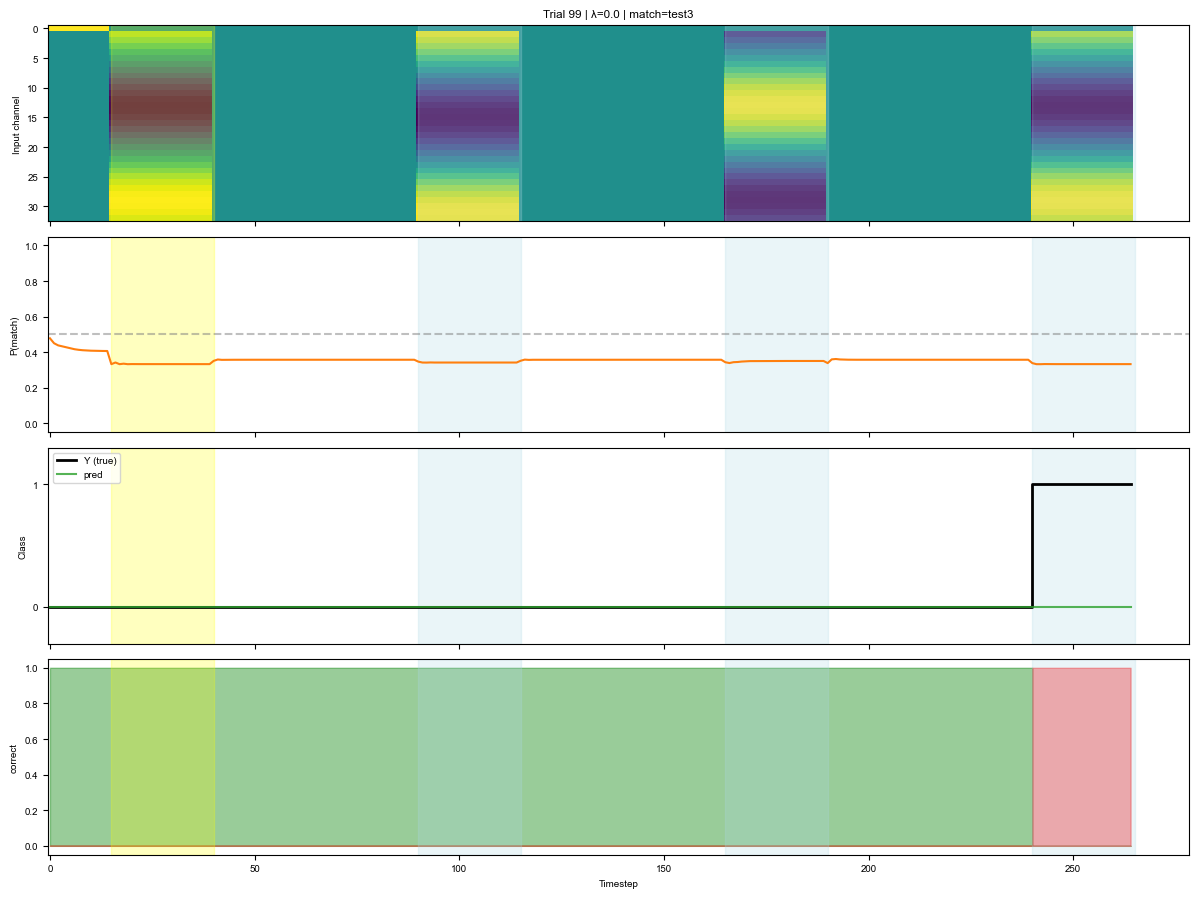

In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os


def inspect_trial(trial_idx=0, lam=0.0, seed=123, checkpoint_dir=None,
                  hidden_size=64, device=None, plot=True):
    """
    Run a single trial through the saved model and return its outputs.

    Returns a dict with input, logits, probs, preds, ground_truth label sequence,
    sample angle, period boundaries, and distractor mask.
    """
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    if checkpoint_dir is None:
        checkpoint_dir = os.path.join('checkpoints', f'distractor_{lam}')

    # Load latest checkpoint
    ckpts = sorted([f for f in os.listdir(checkpoint_dir) if f.endswith('.pt')])
    latest = os.path.join(checkpoint_dir, ckpts[-1])
    print(f"Loading: {latest}")

    # Generate enough trials to cover trial_idx
    n_trials = max(trial_idx + 1, 10)
    X, Y, _, info, mask = generate_trials2(
        num_trials=n_trials, distractor_strength=lam, seed=seed
    )

    # Infer output size from Y
    output_size = int(np.max(Y)) + 1

    # Load model
    model = VanillaRNN(input_size=33, hidden_size=hidden_size, output_size=output_size)
    state = torch.load(latest, map_location=device, weights_only=False)
    if isinstance(state, dict) and 'model_state_dict' in state:
        model.load_state_dict(state['model_state_dict'])
    else:
        model.load_state_dict(state)
    model.to(device).eval()

    # Get period boundaries
    env = DelayMatchSampleDistractor1D(dt=20)
    env.new_trial()
    periods = ['fixation', 'sample', 'delay1', 'test1',
               'delay2', 'test2', 'delay3', 'test3']
    boundaries = {}
    t = 0
    for p in periods:
        steps = int(env.timing[p] / env.dt)
        boundaries[p] = (t, t + steps)
        t += steps

    # Forward pass on just the chosen trial
    with torch.no_grad():
        x = torch.tensor(X[trial_idx:trial_idx+1], dtype=torch.float32).to(device)
        out = model(x)
        logits = out[0] if isinstance(out, tuple) else out
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        preds = logits.argmax(dim=-1).cpu().numpy()[0]
        logits = logits.cpu().numpy()[0]

    gt_label = int(info['ground_truth'][trial_idx])
    sample_angle = float(info['sample_angle'][trial_idx])
    y_true = Y[trial_idx]  # per-timestep ground truth sequence

    # Text summary
    print(f"\nTrial {trial_idx} | sample angle: {sample_angle:.2f} rad | "
          f"match is test{gt_label}")
    for tp in [1, 2, 3]:
        s, e = boundaries[f'test{tp}']
        counts = np.bincount(preds[s:e], minlength=output_size)
        tag = "MATCH" if tp == gt_label else "non-match"
        print(f"  test{tp} ({tag}): preds={counts.tolist()}, "
              f"mean P(match)={probs[s:e, 1].mean():.3f}")

    result = {
        'input': X[trial_idx],
        'y_true': y_true,
        'logits': logits,
        'probs': probs,
        'preds': preds,
        'ground_truth': gt_label,
        'sample_angle': sample_angle,
        'boundaries': boundaries,
        'distractor_mask': mask[trial_idx],
    }

    if plot:
        fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

        # Input heatmap
        axes[0].imshow(X[trial_idx].T, aspect='auto', cmap='viridis')
        axes[0].set_ylabel('Input channel')
        axes[0].set_title(f'Trial {trial_idx} | λ={lam} | match=test{gt_label}')

        # P(match)
        axes[1].plot(probs[:, 1], color='C1')
        axes[1].set_ylabel('P(match)')
        axes[1].set_ylim(-0.05, 1.05)
        axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)

        # Predicted vs true class
        axes[2].plot(y_true, color='black', linewidth=2,
                     label='Y (true)', drawstyle='steps-post')
        axes[2].plot(preds, color='C2', linewidth=1.5, alpha=0.8,
                     label='pred', drawstyle='steps-post')
        axes[2].set_ylabel('Class')
        axes[2].set_yticks(range(output_size))
        axes[2].legend(loc='upper left')
        axes[2].set_ylim(-0.3, output_size - 0.7)

        # Agreement mask (1 = correct, 0 = wrong)
        correct = (preds == y_true).astype(int)
        axes[3].fill_between(range(len(correct)), 0, correct,
                             color='green', alpha=0.4, step='post')
        axes[3].fill_between(range(len(correct)), 0, 1 - correct,
                             color='red', alpha=0.4, step='post')
        axes[3].set_ylabel('correct')
        axes[3].set_ylim(-0.05, 1.05)
        axes[3].set_xlabel('Timestep')

        # Shade periods and mark distractors on all subplots
        shade = {'sample': 'yellow', 'test1': 'lightblue',
                 'test2': 'lightblue', 'test3': 'lightblue'}
        for p, (s, e) in boundaries.items():
            if p in shade:
                for ax in axes:
                    ax.axvspan(s, e, alpha=0.25, color=shade[p])

        for t_step in np.where(mask[trial_idx])[0]:
            axes[0].axvline(t_step, color='red', alpha=0.4, linewidth=0.8)

        plt.tight_layout()
        plt.show()

    return result


# Example usage
result = inspect_trial(trial_idx=99, lam=0.0, seed=123)